EIT ACT3
Arus AC 28.8 kHz
32 elektroda
2 Sinyal Tegangan:
- real          -> efek resistif/konduktif, muncul dari perbedaan konduktivitas
- quadrature    -> respons reaktif/kapasitif

Rumus tegangan kompleks:
V_complex = V_real + 1j * V_quadrature


D-Bar method 
- untuk inverse conductivity problem pakai Dirichlet-to-Neumann (DN) map


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pyeit.mesh as mesh
import pyeit.eit.protocol as protocol
import pyeit.eit.greit as greit

In [3]:
BASE = ""

ACT2006r = BASE + "ACT2006r.txt"   # homogeneous saline real
ACT2006q = BASE + "ACT2006q.txt"   # homogeneous saline quadrature
ACT2000r = BASE + "ACT2000r.txt"   # phantom real
ACT2000q = BASE + "ACT2000q.txt"   # phantom quadrature
SSOUT   = BASE + "ssout1.dat"      # trigonometric current patterns


def load_voltage_file(path):
    raw = np.loadtxt(path)

    # Baris pertama = amplitudo arus maksimum
    current_amplitude = raw[0]

    # Sisanya harus 992 = 31 pola × 32 elektroda
    values = raw[1:]

    if values.size != 31 * 32:
        raise ValueError(f"{path} harus punya 992 data setelah baris pertama, tapi dapat {values.size}")

    values = values.reshape(31, 32)

    # Hilangkan offset tegangan tiap pola
    values = values - values.mean(axis=1, keepdims=True)

    return current_amplitude, values


def load_current_patterns(path, current_amplitude):
    raw = np.loadtxt(path)

    if raw.size != 31 * 32:
        raise ValueError(f"{path} harus punya 992 data, tapi dapat {raw.size}")

    # ssout1.dat berisi pola arus trigonometri
    I = raw.reshape(31, 32)

    # Skala dengan amplitudo arus dari file voltage, biasanya 0.2 mA
    I = I * current_amplitude

    return I


# Load voltage
Iamp_ref_r, Vref_r = load_voltage_file(ACT2006r)
Iamp_ref_q, Vref_q = load_voltage_file(ACT2006q)

Iamp_tgt_r, Vtgt_r = load_voltage_file(ACT2000r)
Iamp_tgt_q, Vtgt_q = load_voltage_file(ACT2000q)

# Load current pattern
I_pat = load_current_patterns(SSOUT, Iamp_ref_r)

print("Vref_r:", Vref_r.shape)
print("Vtgt_r:", Vtgt_r.shape)
print("I_pat:", I_pat.shape)
print("Current amplitude:", Iamp_ref_r)

Vref_r: (31, 32)
Vtgt_r: (31, 32)
I_pat: (31, 32)
Current amplitude: 0.2


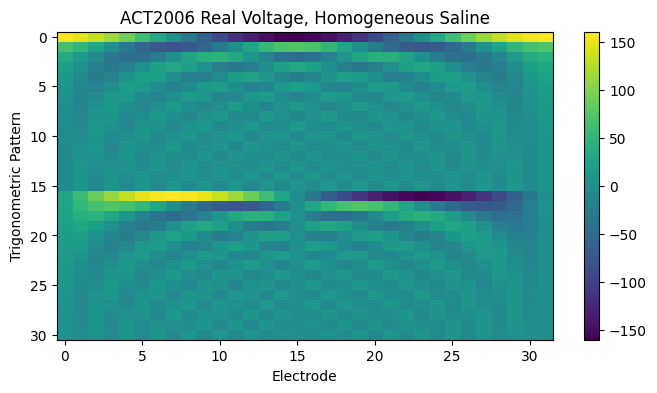

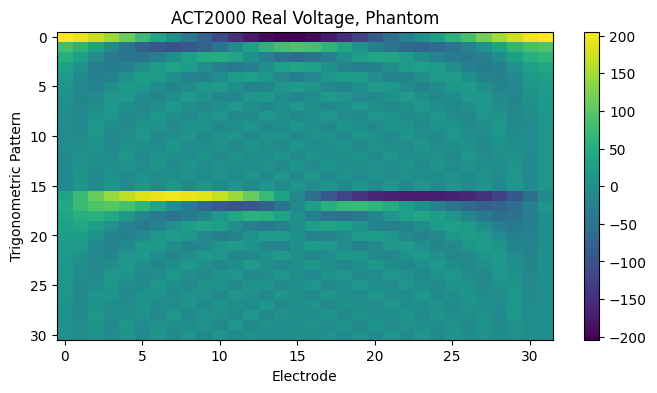

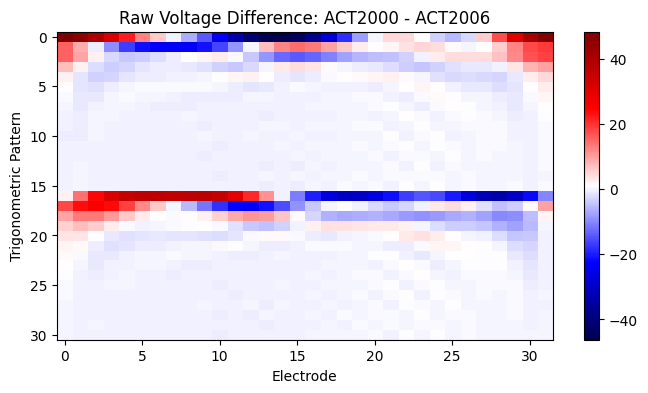

In [4]:
plt.figure(figsize=(8, 4))
plt.imshow(Vref_r, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("ACT2006 Real Voltage, Homogeneous Saline")
plt.xlabel("Electrode")
plt.ylabel("Trigonometric Pattern")
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(Vtgt_r, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("ACT2000 Real Voltage, Phantom")
plt.xlabel("Electrode")
plt.ylabel("Trigonometric Pattern")
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(Vtgt_r - Vref_r, aspect="auto", cmap="seismic")
plt.colorbar()
plt.title("Raw Voltage Difference: ACT2000 - ACT2006")
plt.xlabel("Electrode")
plt.ylabel("Trigonometric Pattern")
plt.show()

In [25]:
n_el = 32

mesh_obj = mesh.create(n_el=n_el, h0=0.06)

protocol_obj = protocol.create(
    n_el=n_el,
    dist_exc=1,
    step_meas=1,
    parser_meas="std"
)

print("ex_mat shape:", np.asarray(protocol_obj.ex_mat).shape)
print("meas_mat shape:", np.asarray(protocol_obj.meas_mat).shape)
print(protocol_obj.meas_mat[0])

ex_mat shape: (32, 2)
meas_mat shape: (32, 29, 2)
[[ 3  2]
 [ 4  3]
 [ 5  4]
 [ 6  5]
 [ 7  6]
 [ 8  7]
 [ 9  8]
 [10  9]
 [11 10]
 [12 11]
 [13 12]
 [14 13]
 [15 14]
 [16 15]
 [17 16]
 [18 17]
 [19 18]
 [20 19]
 [21 20]
 [22 21]
 [23 22]
 [24 23]
 [25 24]
 [26 25]
 [27 26]
 [28 27]
 [29 28]
 [30 29]
 [31 30]]


In [6]:
def synthesize_adjacent_measurements(V_trig, I_trig, protocol_obj, roll=0, sign=1.0):
    """
    Mengubah data ACT trigonometric current pattern menjadi data adjacent pyEIT.

    V_trig: shape (31, 32), voltage measured for trigonometric current patterns
    I_trig: shape (31, 32), trigonometric current patterns
    protocol_obj: pyEIT protocol
    roll: koreksi rotasi elektroda jika citra berputar
    sign: gunakan -1 jika polaritas citra terbalik
    """

    # Koreksi rotasi elektroda jika perlu
    V_trig = np.roll(V_trig, shift=roll, axis=1)
    I_trig = np.roll(I_trig, shift=roll, axis=1)

    # Matrix basis arus
    # Bentuk: 32 elektroda × 31 basis
    B = I_trig.T

    ex_mat = np.asarray(protocol_obj.ex_mat, dtype=int)
    meas_mat = np.asarray(protocol_obj.meas_mat, dtype=int)

    all_meas = []

    for i, ex in enumerate(ex_mat):
        a, b = int(ex[0]), int(ex[1])

        # Desired adjacent current pattern
        c = np.zeros(n_el)
        c[a] = 1.0
        c[b] = -1.0

        # Cari koefisien kombinasi trigonometri yang menghasilkan current adjacent
        coeff, *_ = np.linalg.lstsq(B, c, rcond=None)

        # Sintesis tegangan elektroda dari kombinasi voltage measured
        u = coeff @ V_trig

        # Mean-free voltage
        u = u - np.mean(u)

        # Ambil pasangan pengukuran sesuai protocol pyEIT
        pairs = meas_mat[i]

        for m, n in pairs:
            all_meas.append(sign * (u[int(m)] - u[int(n)]))

    return np.asarray(all_meas)

In [7]:
# Pakai real voltage untuk rekonstruksi konduktivitas
v0 = synthesize_adjacent_measurements(Vref_r, I_pat, protocol_obj, roll=0, sign=1.0)
v1 = synthesize_adjacent_measurements(Vtgt_r, I_pat, protocol_obj, roll=0, sign=1.0)

print("v0 shape:", v0.shape)
print("v1 shape:", v1.shape)
print("Expected pyEIT shape:", 32 * 29)
print("Voltage difference norm:", np.linalg.norm(v1 - v0))

v0 shape: (928,)
v1 shape: (928,)
Expected pyEIT shape: 928
Voltage difference norm: 18.01653905713176


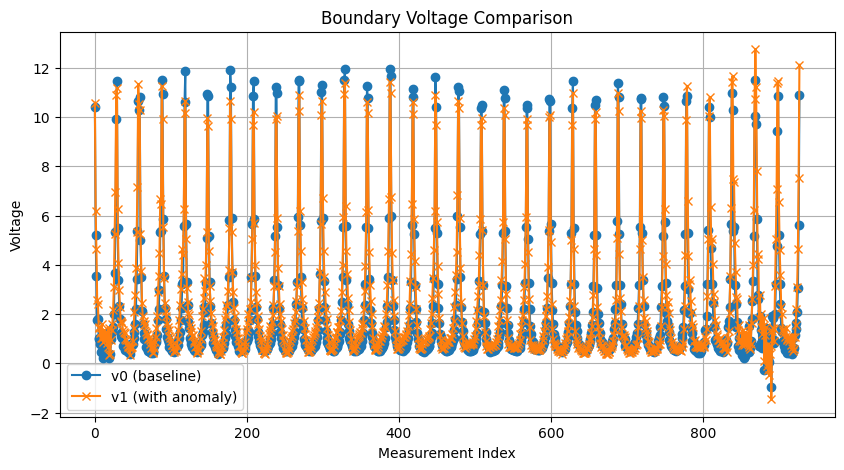

In [13]:
""" Plot boundary voltages """
plt.figure(figsize=(10,5))

plt.plot(v0, label="v0 (baseline)", marker='o')
plt.plot(v1, label="v1 (with anomaly)", marker='x')

plt.title("Boundary Voltage Comparison")
plt.xlabel("Measurement Index")
plt.ylabel("Voltage")
plt.legend()
plt.grid(True)
plt.show()

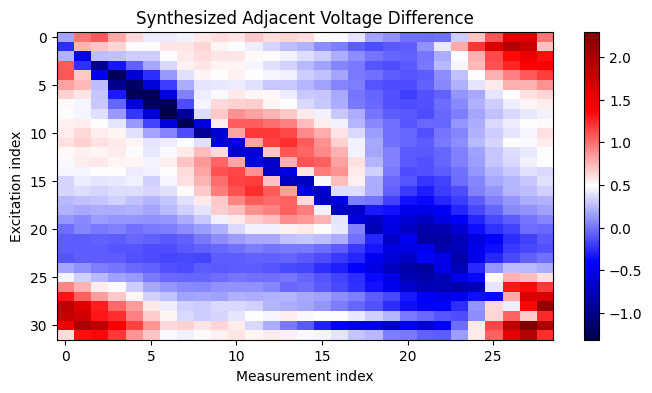

In [8]:
dv = v1 - v0

# Karena 928 = 32 eksitasi × 29 pengukuran
dv_img = dv.reshape(32, 29)

plt.figure(figsize=(8, 4))
plt.imshow(dv_img, aspect="auto", cmap="seismic")
plt.colorbar()
plt.title("Synthesized Adjacent Voltage Difference")
plt.xlabel("Measurement index")
plt.ylabel("Excitation index")
plt.show()

In [9]:
eit = greit.GREIT(mesh_obj, protocol_obj)

eit.setup(
    p=0.50,
    lamb=0.01,
    perm=1.0,
    jac_normalized=True
)

ds = eit.solve(v1, v0, normalize=True)

x, y, ds = eit.mask_value(ds, mask_value=np.nan)

print("Reconstruction shape:", ds.shape)
print("min:", np.nanmin(np.real(ds)))
print("max:", np.nanmax(np.real(ds)))

Reconstruction shape: (32, 32)
min: -1.2114222861115267
max: 0.9114600022435789


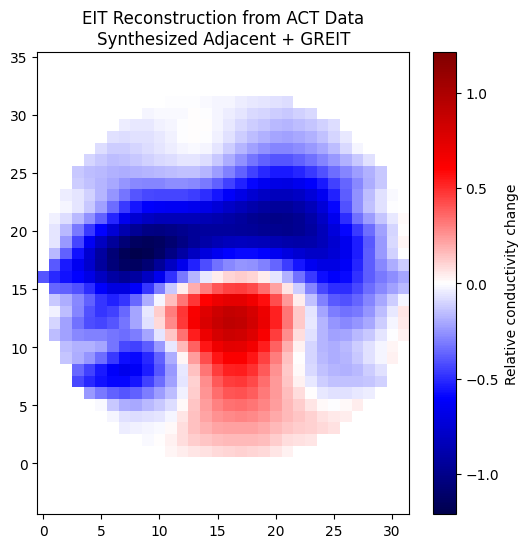

In [10]:
img = np.real(ds)

vmax = np.nanmax(np.abs(img))

plt.figure(figsize=(6, 6))
plt.imshow(
    img,
    cmap="seismic",
    origin="lower",
    interpolation="nearest",
    vmin=-vmax,
    vmax=vmax
)
plt.colorbar(label="Relative conductivity change")
plt.title("EIT Reconstruction from ACT Data\nSynthesized Adjacent + GREIT")
plt.axis("equal")
plt.show()

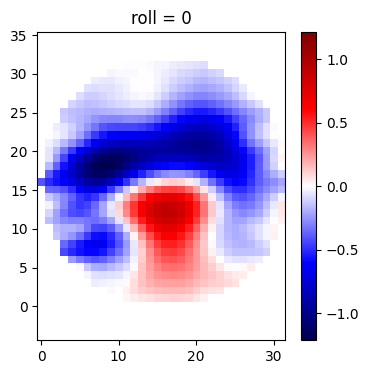

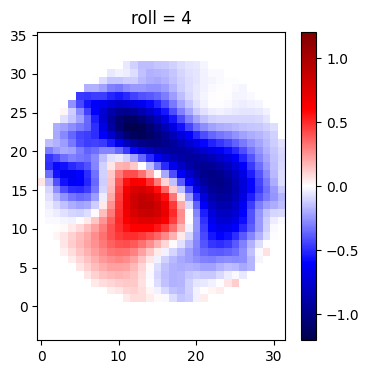

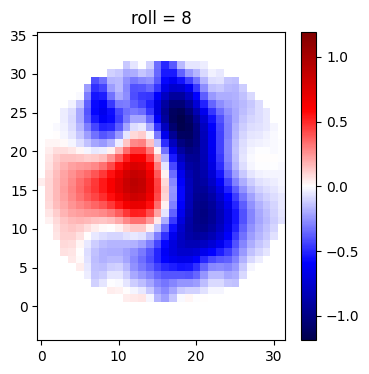

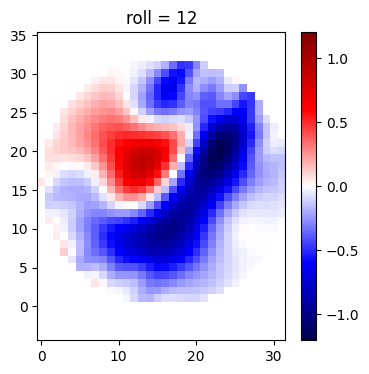

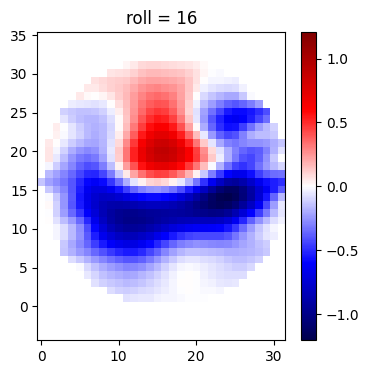

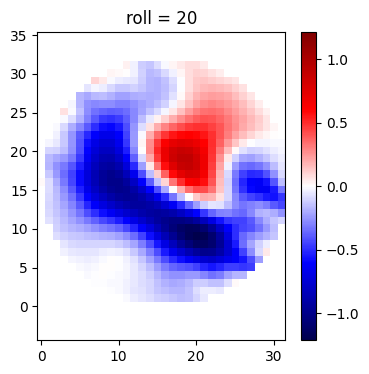

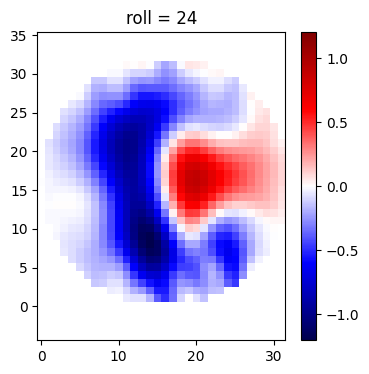

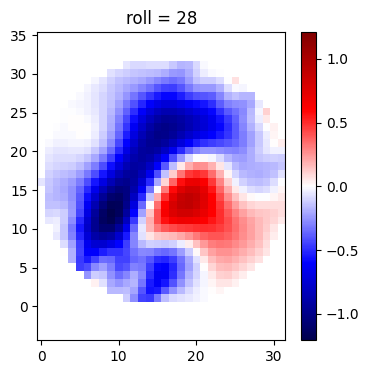

In [11]:
for roll in [0, 4, 8, 12, 16, 20, 24, 28]:
    v0_roll = synthesize_adjacent_measurements(Vref_r, I_pat, protocol_obj, roll=roll, sign=1.0)
    v1_roll = synthesize_adjacent_measurements(Vtgt_r, I_pat, protocol_obj, roll=roll, sign=1.0)

    ds_roll = eit.solve(v1_roll, v0_roll, normalize=True)
    _, _, ds_roll = eit.mask_value(ds_roll, mask_value=np.nan)

    img = np.real(ds_roll)
    vmax = np.nanmax(np.abs(img))

    plt.figure(figsize=(4, 4))
    plt.imshow(
        img,
        cmap="seismic",
        origin="lower",
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax
    )
    plt.title(f"roll = {roll}")
    plt.axis("equal")
    plt.colorbar()
    plt.show()

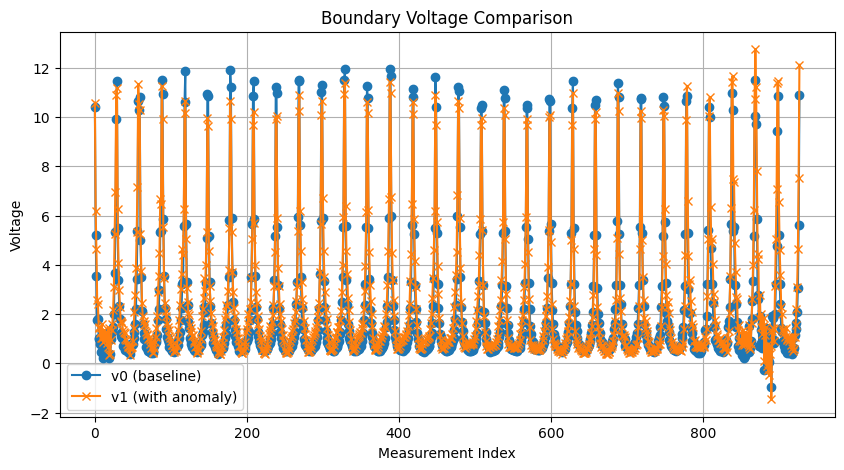

In [12]:
""" Plot boundary voltages """
plt.figure(figsize=(10,5))

plt.plot(v0, label="v0 (baseline)", marker='o')
plt.plot(v1, label="v1 (with anomaly)", marker='x')

plt.title("Boundary Voltage Comparison")
plt.xlabel("Measurement Index")
plt.ylabel("Voltage")
plt.legend()
plt.grid(True)
plt.show()